# Analiza amplitude kalcijumskog odgovora ćelija na tretman kalijumom

## Uvodne napomene

### Cilj

U ovom notebook-u, biće izvršena analiza amplitude odgovora ćelija na tretman kalijumom u vidu porasta unutarćelijske koncentracije kalcijuma, u svrhu karakterisanja raspodele intenziteta ovog odgovora i potencijalnog definisanja njegovog minimalnog intenziteta za posmatranje ćelija kao fiziološki adekvatnih i upotrebljivih u analizi.

Za analizu će se iskoristiti rezultati isključivo onih eksperimenata u kojima su ćelije tretirane prvo rastvorom bogatim kalijumom, bez prethodnog tretmana CSF-om ili blokatorima kanala.

Glavna početna pretpostavka je da se u eksperimentima mogu identifikovati dve subpopulacije ćelija - one koje pokazuju zadovoljavajuć odgovor na K+ i koje se stoga mogu koristiti za pouzdanu analizu njihovog odgovora na CSF, kao i one koje imaju nekarakteristično slab odgovor na K+, što sugeriše da su oštećene ili im je fiziologija na drugi način poremećena, i koje zato treba izbaciti iz analiza.

## Učitavanje podataka

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
RANDOM_STATE = 42

# Folder u kom se nalazi ovaj notebook;
# treba da sadrži podfoldere poput "3_1..10", "4_1..25", itd.
ANALYSIS_ROOT = Path.cwd()

xlsx_files = sorted(
    path for path in ANALYSIS_ROOT.rglob("*.xlsx")
    if not path.name.startswith("~$")
)

print(f"Identifikovano {len(xlsx_files)} Excel fajlova.")

for path in xlsx_files:
    print(path.relative_to(ANALYSIS_ROOT))

Identifikovano 29 Excel fajlova.
10a_1..10/2023_11_01_CGNs_isolated3010_CSF_1.xlsx
10a_1..10/2023_11_01_CGNs_isolated3010_CSF_2.xlsx
10a_1..100/2023_11_02_CGNs_isolated3010_CSF_4.xlsx
10a_1..100/2023_11_02_CGNs_isolated3010_CSF_5.xlsx
10a_1..100/2023_11_02_CGNs_isolated3010_CSF_6_min0.1.xlsx
10a_1..100/2023_11_02_CGNs_isolated3010_CSF_7.xlsx
10a_1..25/2023_11_01_CGNs_isolated3010_CSF_3.xlsx
10a_1..25/2023_11_01_CGNs_isolated3010_CSF_4_min0.1.xlsx
10a_1..25/2023_11_01_CGNs_isolated3010_CSF_5.xlsx
10a_1..50/2023_11_01_CGNs_isolated3010_CSF_7_min0.1.xlsx
10a_1..50/2023_11_02_CGNs_isolated3010_CSF_1.xlsx
10a_1..50/2023_11_02_CGNs_isolated3010_CSF_2.xlsx
10a_1..50/2023_11_02_CGNs_isolated3010_CSF_3_min0.1.xlsx
3_1..10/2024_02_16_CGNs_iso1302_1_min0.1.xlsx
3_1..25/2024_02_16_CGNs_iso1302_4.xlsx
4_1..10/2023_11_11_CGNs_isolated0911_CSF_2_min0.1.xlsx
4_1..10/2023_11_11_CGNs_isolated0911_CSF_3_min0.1.xlsx
4_1..10/2023_11_11_CGNs_isolated0911_CSF_4_min0.1.xlsx
4_1..10/2024_02_04_CGNs_isolated020

## Ekstrakcija vrednosti

In [3]:
def excel_column_letter(column_number: int) -> str:
    """
    Prevodi kolonu Excel fajla u slovni oblik.

    Primer:
        1  -> A
        2  -> B
        26 -> Z
        27 -> AA
    """
    letters = ""

    while column_number:
        column_number, remainder = divmod(column_number - 1, 26)
        letters = chr(65 + remainder) + letters

    return letters

In [4]:
def normalize_label(value) -> str:
    """
    Konvertuje oznaku lista u standardizovan niz sa malim slovima.

    Ovako se izbegavaju problemi u poređenju oznaka poput
    'prvi kalijum', 'Prvi kalijum ', itd.
    """
    if pd.isna(value):
        return ""

    return str(value).strip().lower()

In [5]:
def parse_folder_metadata(path: Path) -> dict:
    """
    Prolazi kroz foldere poput:
    3_1..10
    4_1..25

    Vraća ID pacijenta i razblaženje.
    """
    folder_name = path.parent.name

    patient_match = re.search(
        r"^([A-Za-z0-9]+)",
        folder_name,
    )

    dilution_match = re.search(
        r"1\.\.(\d+)",
        folder_name,
    )

    patient_id = (
        patient_match.group(1)
    )

    dilution = (
        f"1/{dilution_match.group(1)}"
    )

    class_map = {
        "3": "ALS",
        "4": "ALS",
        "7": "Control",
        "10a": "SMA",
        "10b": "SMA",
    }

    class_label = class_map.get(
        str(patient_id),
        "Unknown",
    )

    return {
        "folder_name": folder_name,
        "patient_id": patient_id,
        "dilution": dilution,
        "class_label": class_label,
    }

In [6]:
def get_sheet_first_cells(path: Path) -> pd.DataFrame:
    """
    Prolazi kroz sve listove u fajlu i vraća oznake njihovih A1 ćelija.

    Radi i sa praznim listovima ili onim gde je nemoguće pročitati oznaku.
    """
    excel_file = pd.ExcelFile(path)

    rows = []

    for sheet_index, sheet_name in enumerate(
        excel_file.sheet_names
    ):
        try:
            first_cell_table = pd.read_excel(
                path,
                sheet_name=sheet_name,
                header=None,
                nrows=1,
                usecols=[0],
            )

            if first_cell_table.empty:
                first_cell = np.nan
            else:
                first_cell = first_cell_table.iloc[0, 0]

        except Exception as error:
            first_cell = np.nan

        rows.append(
            {
                "sheet_index": sheet_index,
                "sheet_name": sheet_name,
                "first_cell": first_cell,
                "label_normalized": normalize_label(first_cell),
            }
        )

    return pd.DataFrame(rows)

In [7]:
def detect_first_potassium_sheet(path: Path) -> dict:
    """
    Pronalazi list u kom se nalaze parametri prvog K+ odgovora.

    List mora sadržati 'prvi' i 'kalijum'.
    """
    sheet_labels = get_sheet_first_cells(path)

    labels = sheet_labels["label_normalized"]

    potassium_mask = (
        labels.str.contains("kalijum", regex=False)
    )

    potassium_sheets = sheet_labels.loc[
        potassium_mask
    ].copy()

    if potassium_sheets.empty:
        raise ValueError(
            f"Nema lista s K+ odgovorom u {path.name}"
        )

    first_k_mask = (
        potassium_sheets["label_normalized"]
        .str.contains("prvi", regex=False)
    )

    first_k_sheets = potassium_sheets.loc[
        first_k_mask
    ].copy()

    if not first_k_sheets.empty:
        selected = first_k_sheets.sort_values(
            "sheet_index"
        ).iloc[0]

    return {
        "k_sheet_name": selected["sheet_name"],
        "k_sheet_index": selected["sheet_index"],
        "k_sheet_label": selected["first_cell"],
    }

In [8]:
def safe_summary_row(
    table: pd.DataFrame,
    row_index: int,
    roi_columns,
) -> pd.Series:
    """
    Izvlači vrednosti jednog reda unutar lista s parametrima K+ odgovora
    i konvertuje ih u numeričke.
    """
    if row_index >= len(table):
        return pd.Series(
            np.nan,
            index=roi_columns,
        )

    return pd.to_numeric(
        table.iloc[row_index, 1:],
        errors="coerce",
    )

In [9]:
def extract_first_k_summary(
    path: Path,
) -> pd.DataFrame:
    """
    Izvlači parametre prvog odgovora na K+ iz jednog Excel fajla.
    """
    metadata = parse_folder_metadata(path)
    k_sheet_info = detect_first_potassium_sheet(path)

    table = pd.read_excel(
        path,
        sheet_name=k_sheet_info["k_sheet_name"],
        header=None,
    )

    roi_columns = table.columns[1:]
    n_rois = len(roi_columns)

    result = pd.DataFrame(
        {
            "roi_position": np.arange(1, n_rois + 1),
            "roi_id": [
                f"ROI_{i:03d}"
                for i in range(1, n_rois + 1)
            ],
            "roi_source_excel_column": [
                excel_column_letter(i + 1)
                for i in range(1, n_rois + 1)
            ],
        }
    )

    result["k_ref_amplitude"] = safe_summary_row(
        table,
        13,
        roi_columns,
    ).to_numpy()

    result["k_half_width"] = safe_summary_row(
        table,
        24,
        roi_columns,
    ).to_numpy()

    result["k_peak_location"] = safe_summary_row(
        table,
        35,
        roi_columns,
    ).to_numpy()

    result["k_integral"] = safe_summary_row(
        table,
        46,
        roi_columns,
    ).to_numpy()

    result["k_response_detected"] = (
        result["k_ref_amplitude"].notna()
    )

    for key, value in metadata.items():
        result[key] = value

    result["file_name"] = path.name
    result["relative_path"] = str(
        path.relative_to(ANALYSIS_ROOT)
    )

    for key, value in k_sheet_info.items():
        result[key] = value

    return result

In [10]:
def extract_trace_qc(path: Path) -> pd.DataFrame:
    """
    Računa udeo negativnih vrednosti u kolonama lista sa normalizovanim
    podacima o intenzitetu fluorescencije u ćelijama.
    """
    table = pd.read_excel(
        path,
        sheet_name="Sheet2",
        header=None,
    )

    roi_columns = table.columns[1:]
    n_rois = len(roi_columns)

    traces = table.iloc[:, 1:].apply(
        pd.to_numeric,
        errors="coerce",
    )

    n_valid_points = traces.notna().sum(axis=0)

    negative_fraction = (
        (traces < 0).sum(axis=0)
        / n_valid_points.replace(0, np.nan)
    )

    qc = pd.DataFrame(
        {
            "roi_position": np.arange(1, n_rois + 1),
            "roi_id": [
                f"ROI_{i:03d}"
                for i in range(1, n_rois + 1)
            ],
            "roi_source_excel_column": [
                excel_column_letter(i + 1)
                for i in range(1, n_rois + 1)
            ],
            "normalized_negative_fraction": (
                negative_fraction.to_numpy()
            ),
        }
    )

    qc["majority_negative_trace"] = (
        qc["normalized_negative_fraction"] > 0.5
    )

    return qc

In [11]:
# Ekstrakcija iz svih fajlova
all_k_tables = []
failed_files = []

for path in xlsx_files:
    try:
        k_table = extract_first_k_summary(path)

        try:
            trace_qc = extract_trace_qc(path)

            k_table = k_table.merge(
                trace_qc,
                on=[
                    "roi_position",
                    "roi_id",
                    "roi_source_excel_column",
                ],
                how="left",
            )

        except Exception as qc_error:
            print(
                f"trace_qc greška: {path.name}: "
                f"{qc_error}"
            )

            k_table["normalized_negative_fraction"] = np.nan
            k_table["majority_negative_trace"] = np.nan

        all_k_tables.append(k_table)

    except Exception as error:
        failed_files.append(
            {
                "relative_path": str(
                    path.relative_to(ANALYSIS_ROOT)
                ),
                "error": str(error),
            }
        )

k_all = pd.concat(
    all_k_tables,
    ignore_index=True,
)

failed_files = pd.DataFrame(failed_files)

print("Dimenzije ekstrahovane K+ tabele:", k_all.shape)
print("Neuspelo fajlova:", len(failed_files))

Dimenzije ekstrahovane K+ tabele: (5628, 19)
Neuspelo fajlova: 0


In [12]:
# Kreiranje jedinstvenih oznaka
k_all["experiment_source_id"] = (
    k_all["folder_name"].astype(str)
    + "__"
    + k_all["file_name"].astype(str)
)

k_all["record_id"] = (
    k_all["experiment_source_id"]
    + "__"
    + k_all["roi_id"]
)

# Obeležavanje ćelija s validnim signalom
k_all["majority_negative_trace"] = (
    k_all["majority_negative_trace"]
    .fillna(False)
    .astype(bool)
)

In [13]:
# Provera ekstrahovanih listova
selected_k_sheets = (
    k_all[
        [
            "experiment_source_id",
            "folder_name",
            "patient_id",
            "dilution",
            "class_label",
            "file_name",
            "k_sheet_name",
            "k_sheet_label",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "folder_name",
            "file_name",
        ]
    )
)

selected_k_sheets

,experiment_source_id,folder_name,patient_id,dilution,class_label,file_name,k_sheet_name,k_sheet_label
0,10a_1..10__2023_11_01_CGNs_isolated3010_CSF_1....,10a_1..10,10a,1/10,SMA,2023_11_01_CGNs_isolated3010_CSF_1.xlsx,Sheet3,prvi kalijum
202,10a_1..10__2023_11_01_CGNs_isolated3010_CSF_2....,10a_1..10,10a,1/10,SMA,2023_11_01_CGNs_isolated3010_CSF_2.xlsx,Sheet3,prvi kalijum
426,10a_1..100__2023_11_02_CGNs_isolated3010_CSF_4...,10a_1..100,10a,1/100,SMA,2023_11_02_CGNs_isolated3010_CSF_4.xlsx,Sheet3,prvi kalijum
639,10a_1..100__2023_11_02_CGNs_isolated3010_CSF_5...,10a_1..100,10a,1/100,SMA,2023_11_02_CGNs_isolated3010_CSF_5.xlsx,Sheet3,prvi kalijum
793,10a_1..100__2023_11_02_CGNs_isolated3010_CSF_6...,10a_1..100,10a,1/100,SMA,2023_11_02_CGNs_isolated3010_CSF_6_min0.1.xlsx,Sheet3,prvi kalijum
1001,10a_1..100__2023_11_02_CGNs_isolated3010_CSF_7...,10a_1..100,10a,1/100,SMA,2023_11_02_CGNs_isolated3010_CSF_7.xlsx,Sheet3,prvi kalijum
1161,10a_1..25__2023_11_01_CGNs_isolated3010_CSF_3....,10a_1..25,10a,1/25,SMA,2023_11_01_CGNs_isolated3010_CSF_3.xlsx,Sheet3,prvi kalijum
1410,10a_1..25__2023_11_01_CGNs_isolated3010_CSF_4_...,10a_1..25,10a,1/25,SMA,2023_11_01_CGNs_isolated3010_CSF_4_min0.1.xlsx,Sheet3,prvi kalijum
1676,10a_1..25__2023_11_01_CGNs_isolated3010_CSF_5....,10a_1..25,10a,1/25,SMA,2023_11_01_CGNs_isolated3010_CSF_5.xlsx,Sheet3,prvi kalijum
1908,10a_1..50__2023_11_01_CGNs_isolated3010_CSF_7_...,10a_1..50,10a,1/50,SMA,2023_11_01_CGNs_isolated3010_CSF_7_min0.1.xlsx,Sheet3,prvi kalijum


In [14]:
# Filtriranje ROI sa K+ odgovorom
k_amp_df = k_all.loc[
    k_all["k_response_detected"]
    & k_all["k_ref_amplitude"].notna()
].copy()

print("Ukupno ROI:", len(k_all))
print("ROI sa K+ amplitudom:", len(k_amp_df))

Ukupno ROI: 5628
ROI sa K+ amplitudom: 4877


## Analiza raspodele amplitude

In [15]:
# Sažetak po fajlu i folderu
analysis_df = k_amp_df.copy()

k_file_summary = (
    analysis_df
    .groupby(
        [
            "folder_name",
            "patient_id",
            "dilution",
            "class_label",
            "file_name",
        ],
        dropna=False,
    )
    .agg(
        n_rois=("record_id", "count"),
        median_k_ref_amplitude=("k_ref_amplitude", "median"),
        mean_k_ref_amplitude=("k_ref_amplitude", "mean"),
        min_k_ref_amplitude=("k_ref_amplitude", "min"),
        max_k_ref_amplitude=("k_ref_amplitude", "max"),
    )
    .reset_index()
)

k_file_summary.sort_values("median_k_ref_amplitude")

,folder_name,patient_id,dilution,class_label,file_name,n_rois,median_k_ref_amplitude,mean_k_ref_amplitude,min_k_ref_amplitude,max_k_ref_amplitude
19,4_1..25,4,1/25,ALS,2023_11_11_CGNs_isolated0911_CSF_5_min0.1.xlsx,106,1.062639,1.312189,0.238480,3.456264
0,10a_1..10,10a,1/10,SMA,2023_11_01_CGNs_isolated3010_CSF_1.xlsx,151,1.291793,1.324066,0.547411,2.652679
23,7_1..10,7,1/10,Control,2023_11_17_CGNs_isolated1511_CSF_3_min0.1.xlsx,117,1.355008,1.663021,0.298509,4.612199
17,4_1..10,4,1/10,ALS,2023_11_11_CGNs_isolated0911_CSF_4_min0.1.xlsx,145,1.598435,1.770466,0.474389,4.390157
16,4_1..10,4,1/10,ALS,2023_11_11_CGNs_isolated0911_CSF_3_min0.1.xlsx,95,1.794762,2.108897,0.618305,5.647290
6,10a_1..25,10a,1/25,SMA,2023_11_01_CGNs_isolated3010_CSF_3.xlsx,229,2.013582,2.174485,0.591613,5.159104
1,10a_1..10,10a,1/10,SMA,2023_11_01_CGNs_isolated3010_CSF_2.xlsx,208,2.301310,2.341276,0.665177,4.260605
15,4_1..10,4,1/10,ALS,2023_11_11_CGNs_isolated0911_CSF_2_min0.1.xlsx,103,2.383202,2.426859,0.101939,5.372791
7,10a_1..25,10a,1/25,SMA,2023_11_01_CGNs_isolated3010_CSF_4_min0.1.xlsx,240,2.753613,2.731171,0.818005,4.859580
8,10a_1..25,10a,1/25,SMA,2023_11_01_CGNs_isolated3010_CSF_5.xlsx,204,2.791988,2.817960,0.936388,5.058194


In [16]:
# Sažetak po razblaženju i klasi
k_dilution_summary = (
    analysis_df
    .groupby(
        [
            "dilution",
            "class_label",
        ],
        dropna=False,
    )
    .agg(
        n_rois=("record_id", "count"),
        median_k_ref_amplitude=("k_ref_amplitude", "median"),
        mean_k_ref_amplitude=("k_ref_amplitude", "mean"),
        min_k_ref_amplitude=("k_ref_amplitude", "min"),
        max_k_ref_amplitude=("k_ref_amplitude", "max"),
    )
    .reset_index()
)

k_dilution_summary

,dilution,class_label,n_rois,median_k_ref_amplitude,mean_k_ref_amplitude,min_k_ref_amplitude,max_k_ref_amplitude
0,1/10,ALS,612,2.307902,2.619088,0.101939,6.979507
1,1/10,Control,830,4.369826,4.169585,0.158665,8.949427
2,1/10,SMA,359,1.758022,1.913424,0.547411,4.260605
3,1/100,SMA,676,4.174722,4.073180,0.124925,7.101962
4,1/25,ALS,566,4.416345,4.169716,0.238480,8.533885
5,1/25,Control,367,4.078318,4.010744,0.490061,6.111695
6,1/25,SMA,673,2.570586,2.568056,0.591613,5.159104
7,1/50,ALS,85,3.235868,3.331806,0.103537,6.659727
8,1/50,SMA,709,3.606969,3.539751,0.114450,6.215585


In [17]:
# Prikaz amplitude po postotcima
k_ref_amplitude_summary = analysis_df["k_ref_amplitude"].describe(
    percentiles=[
        0.01,
        0.025,
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.975,
        0.99,
    ]
)

k_ref_amplitude_summary

count    4877.000000
mean        3.456473
std         1.510329
min         0.101939
1%          0.631351
2.5%        0.859780
5%          1.070417
10%         1.446991
25%         2.275589
50%         3.498740
75%         4.514467
90%         5.347160
95%         5.939559
97.5%       6.460650
99%         7.237068
max         8.949427
Name: k_ref_amplitude, dtype: float64

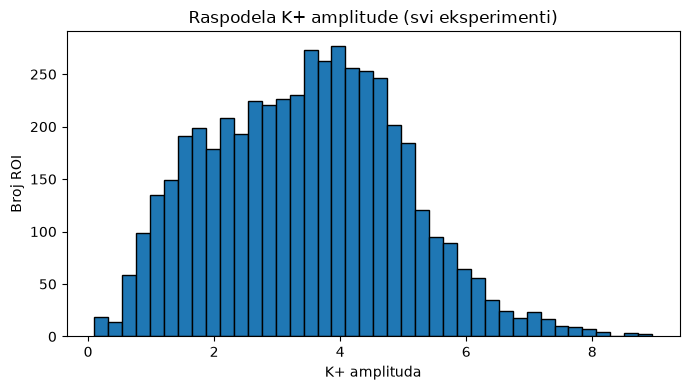

In [18]:
# Vizuelizacija raspodele amplitude
plt.figure(figsize=(7, 4))

plt.hist(
    analysis_df["k_ref_amplitude"],
    bins=40,
    edgecolor="black",
)

plt.xlabel("K+ amplituda")
plt.ylabel("Broj ROI")
plt.title("Raspodela K+ amplitude (svi eksperimenti)")
plt.tight_layout()
plt.show()

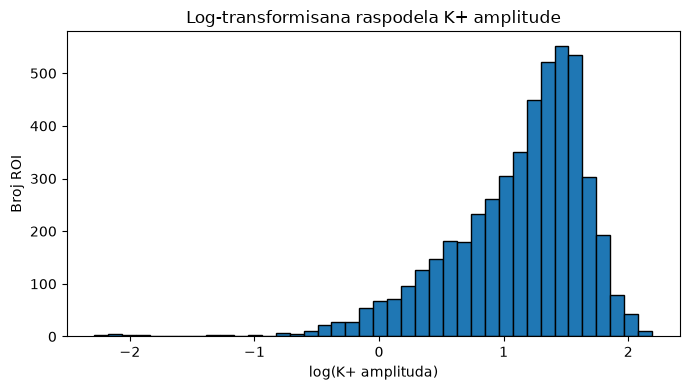

In [19]:
# Log-transformisana raspodela
analysis_df["log_k_ref_amplitude"] = np.log(
    analysis_df["k_ref_amplitude"]
)

plt.figure(figsize=(7, 4))

plt.hist(
    analysis_df["log_k_ref_amplitude"],
    bins=40,
    edgecolor="black",
)

plt.xlabel("log(K+ amplituda)")
plt.ylabel("Broj ROI")
plt.title("Log-transformisana raspodela K+ amplitude")
plt.tight_layout()
plt.show()

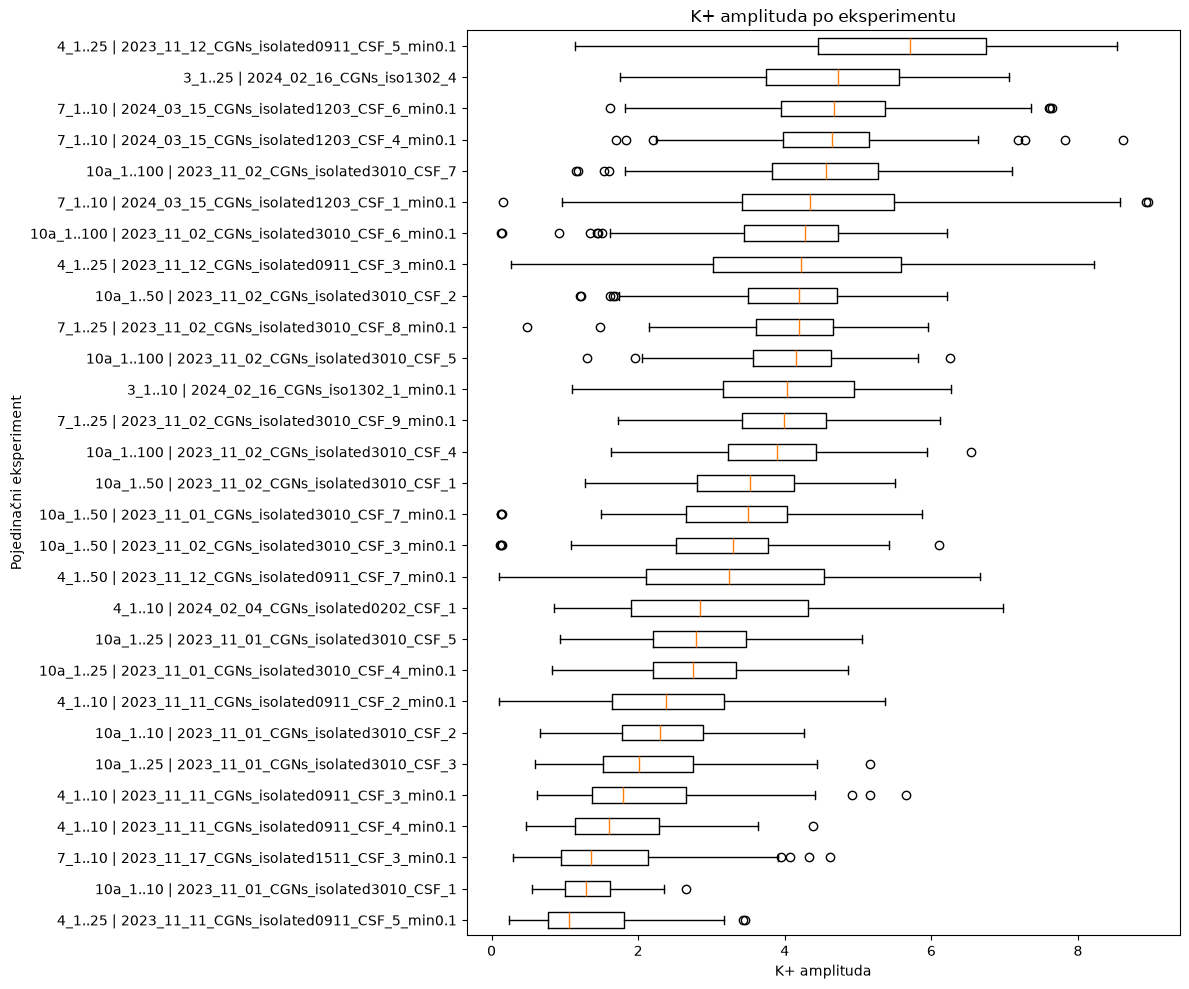

In [20]:
# Boksplot grafik po eksperimentu

# Kraće oznake eksperimenata
analysis_df["experiment_label"] = (
    analysis_df["folder_name"].astype(str)
    + " | "
    + analysis_df["file_name"]
    .str.replace(".xlsx", "", regex=False)
)

# Definisanje redosleda
group_column = "experiment_label"

experiment_order = (
    analysis_df
    .groupby("experiment_label")["k_ref_amplitude"]
    .median()
    .sort_values()
    .index
    .tolist()
)

# Vizuelizacija
data_to_plot = [
    analysis_df.loc[
        analysis_df["experiment_label"] == experiment,
        "k_ref_amplitude",
    ].dropna()
    for experiment in experiment_order
]

plt.figure(figsize=(12, 10))

plt.boxplot(
    data_to_plot,
    tick_labels=experiment_order,
    orientation='horizontal',
)

plt.xlabel("K+ amplituda")
plt.ylabel("Pojedinačni eksperiment")
plt.title("K+ amplituda po eksperimentu")
plt.tight_layout()
plt.show()

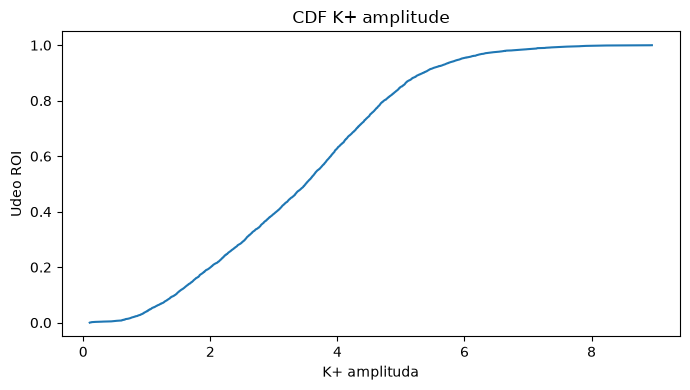

In [21]:
# Kumulativna raspodela
values = np.sort(
    analysis_df["k_ref_amplitude"].dropna().to_numpy()
)

cdf = np.arange(1, len(values) + 1) / len(values)

plt.figure(figsize=(7, 4))

plt.plot(values, cdf)

plt.xlabel("K+ amplituda")
plt.ylabel("Udeo ROI")
plt.title("CDF K+ amplitude")
plt.tight_layout()
plt.show()

Ono što zasad vidimo jeste da je opseg vrednosti K+ amplitude veoma veliki kada su u pitanju pojedinačne ćelije, ali i kada su u pitanju odvojeni eksperimenti, sa medijalnim amplitudama po eksperimentu u opsegu od `1.1` do `5.7`, pri čemu je ukupna medijalna vrednost `3.5`. Na osnovu histograma ne primećujemo jasno definisane subpopulacije ćelija, ali ovo možemo dalje ispitati; na primer, pomoću *Gaussian mixture* modela, koji može ukazati na postojanje više preklapajućih populacija ćelija sa normalnom raspodelom amplitude. 

Pre toga ćemo brzo ispitati nekoliko potencijalnih graničnih vrednosti za K+ amplitudu i proveriti šta bi one značile za celokupan set podataka. 

In [22]:
# Potencijalne granice odgovora
q01 = analysis_df["k_ref_amplitude"].quantile(0.01)
q025 = analysis_df["k_ref_amplitude"].quantile(0.025)
q05 = analysis_df["k_ref_amplitude"].quantile(0.05)
q10 = analysis_df["k_ref_amplitude"].quantile(0.10)
q15 = analysis_df["k_ref_amplitude"].quantile(0.15)

candidate_thresholds = pd.DataFrame(
    {
        "threshold_name": [
            "1. postotak",
            "2.5. postotak",
            "5. postotak",
            "10. postotak",
            "15. postotak",
        ],
        "k_ref_amplitude_threshold": [
            q01,
            q025,
            q05,
            q10,
            q15,
        ],
        "n_flagged": [
            (analysis_df["k_ref_amplitude"] < q01).sum(),
            (analysis_df["k_ref_amplitude"] < q025).sum(),
            (analysis_df["k_ref_amplitude"] < q05).sum(),
            (analysis_df["k_ref_amplitude"] < q10).sum(),
            (analysis_df["k_ref_amplitude"] < q15).sum(),
        ],
    }
)

candidate_thresholds

,threshold_name,k_ref_amplitude_threshold,n_flagged
0,1. postotak,0.631351,49
1,2.5. postotak,0.859780,122
2,5. postotak,1.070417,244
3,10. postotak,1.446991,488
4,15. postotak,1.727472,732


Vidimo kolika bi bila granična vrednost amplitude za različite postotke ukupnog seta podataka. Međutim, ovo suštinski nije od značaja, jer su ove potencijalne granice sasvim arbitrarne i (barem naizgled) ne odgovaraju nikakvim biološki značajnim razlikama.

### Modeliranje multimodalnosti

Potencijalnu multimodalnost isprobaćemo preko modela Gausove mešavine, koji se koristi za ispitivanje postojanja više preklapajućih normalnih raspodela u okviru veće raspodele. Performanse ovakvog modela procenjuju se preko **BIC** i **AIC** vrednosti, koje su niže ukoliko se model sa zadatim brojem komponenti bolje poklapaju sa podacima, čak i kada se model penalizuje usled povećane složenosti.

In [23]:
from sklearn.mixture import GaussianMixture

In [24]:
# Kreiranje Gaussian Mixture modela
X_log_k = (
    analysis_df["log_k_ref_amplitude"]
    .dropna()
    .to_numpy()
    .reshape(-1, 1)
)

gmm_rows = []

for n_components in [1, 2, 3]:
    gmm = GaussianMixture(
        n_components=n_components,
        random_state=RANDOM_STATE,
    )

    gmm.fit(X_log_k)

    gmm_rows.append(
        {
            "n_components": n_components,
            "bic": gmm.bic(X_log_k),
            "aic": gmm.aic(X_log_k),
        }
    )

gmm_comparison = pd.DataFrame(gmm_rows)

gmm_comparison

,n_components,bic,aic
0,1,8028.226843,8015.242272
1,2,6973.452731,6940.991303
2,3,6849.829324,6797.891039


Vidimo da model sa dve komponente ima znatno bolje performanse od modela sa samo jednom komponentom, dok je model sa tri komponente nešto bolji od onog sa dve; ipak, za potrebe naše analize, modeliranje tri ili više potencijalnih populacija ćelija nije od preterane koristi. Istovremeno, ono što je veoma značajno jeste činjenica da posmatramo sve ćelije odjednom, a već smo videli znatne razlike u raspodelama vrednosti K+ amplitude među eksperimentima; stoga, bilo kakve identifikovane subpopulacije ćelija verovatno ne odgovaraju grupama sa biološki relevantnim razlikama, već najpre potiču od razlika specifičnih za eksperiment.

Za sada ćemo fitovati dvokomponentni model na naše podatke u svrhu ispitivanja postojanja dve manje ili više dobro definisane subpopulacije ćelija.

In [25]:
# Fitovanje dvokomponentnog modela
gmm_2 = GaussianMixture(
    n_components=2,
    random_state=RANDOM_STATE,
)

gmm_2.fit(X_log_k)

,"n_components n_components: int, default=1The number of mixture components.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None


In [26]:
# Kriva gustine
x_grid = np.linspace(
    X_log_k.min(),
    X_log_k.max(),
    1000,
).reshape(-1, 1)

component_means = gmm_2.means_.ravel()
component_vars = gmm_2.covariances_.ravel()
component_sds = np.sqrt(component_vars)
component_weights = gmm_2.weights_.ravel()

component_densities = []

for mean, sd, weight in zip(
    component_means,
    component_sds,
    component_weights,
):
    density = (
        weight
        * (1 / (sd * np.sqrt(2 * np.pi)))
        * np.exp(
            -0.5
            * ((x_grid.ravel() - mean) / sd) ** 2
        )
    )

    component_densities.append(density)

total_density = np.sum(
    component_densities,
    axis=0,
)

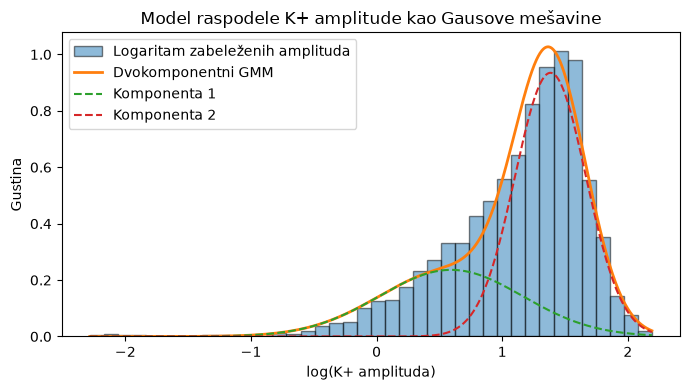

In [27]:
# Vizuelizacija
plt.figure(figsize=(7, 4))

plt.hist(
    X_log_k.ravel(),
    bins=40,
    density=True,
    alpha=0.5,
    edgecolor="black",
    label="Logaritam zabeleženih amplituda",
)

plt.plot(
    x_grid.ravel(),
    total_density,
    linewidth=2,
    label="Dvokomponentni GMM",
)

for i, density in enumerate(component_densities):
    plt.plot(
        x_grid.ravel(),
        density,
        linestyle="--",
        label=f"Komponenta {i + 1}",
    )

plt.xlabel("log(K+ amplituda)")
plt.ylabel("Gustina")
plt.title("Model raspodele K+ amplitude kao Gausove mešavine")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
# Identifikacija komponente sa slabim odgovorom
low_component = np.argmin(
    gmm_2.means_.ravel()
)

component_probabilities = gmm_2.predict_proba(X_log_k)

low_component_probability = (
    component_probabilities[:, low_component]
)

# Dodavanje vrednosti u tabelu
analysis_df = analysis_df.loc[
    analysis_df["log_k_ref_amplitude"].notna()
].copy()

analysis_df["weak_k_component_probability"] = (
    low_component_probability
)

analysis_df["weak_k_component_flag_90"] = (
    analysis_df["weak_k_component_probability"] >= 0.90
)

analysis_df["weak_k_component_flag_75"] = (
    analysis_df["weak_k_component_probability"] >= 0.75
)

In [29]:
# Provera raspodele verovatnoće pripadanja slaboj komponenti
analysis_df[
    [
        "weak_k_component_probability",
    ]
].describe()

,weak_k_component_probability
count,4877.000000
mean,0.343872
std,0.355546
min,0.065655
25%,0.074737
50%,0.127718
75%,0.626605
max,1.000000


In [30]:
# Broj ROI s datom verovatnoćom pripadanja slaboj komponenti
analysis_df[
    [
        "weak_k_component_flag_90",
        "weak_k_component_flag_75",
    ]
].sum()

weak_k_component_flag_90     867
weak_k_component_flag_75    1065
dtype: int64

In [31]:
# Procena granične vrednosti
grid_probabilities = gmm_2.predict_proba(x_grid)

low_component_grid_probability = (
    grid_probabilities[:, low_component]
)

# Tačka sa 50% verovatnoćom pripadanja obema komponentama
threshold_index = np.argmin(
    np.abs(low_component_grid_probability - 0.5)
)

log_threshold = x_grid.ravel()[threshold_index]
amplitude_threshold = np.exp(log_threshold)

amplitude_threshold

np.float64(2.44134833776637)

In [32]:
# Obeležavanje ROI ispod granice
analysis_df["weak_k_below_gmm_threshold"] = (
    analysis_df["k_ref_amplitude"]
    < amplitude_threshold
)

analysis_df["weak_k_below_gmm_threshold"].value_counts()

weak_k_below_gmm_threshold
False    3507
True     1370
Name: count, dtype: int64

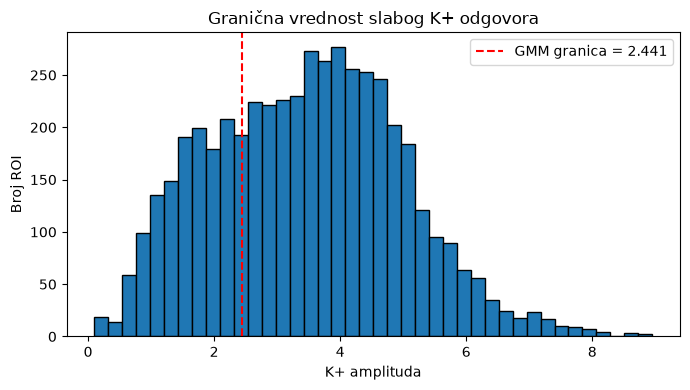

In [33]:
# Vizuelizacija
plt.figure(figsize=(7, 4))

plt.hist(
    analysis_df["k_ref_amplitude"],
    bins=40,
    edgecolor="black",
)

plt.axvline(
    amplitude_threshold,
    linestyle="--",
    color="red",
    label=f"GMM granica = {amplitude_threshold:.3f}",
)

plt.xlabel("K+ amplituda")
plt.ylabel("Broj ROI")
plt.title("Granična vrednost slabog K+ odgovora")
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
# Udeo slabih odgovora po eksperimentu
weak_k_by_experiment = (
    analysis_df
    .groupby(
        [
            "experiment_source_id",
            "patient_id",
            "class_label",
        ]
    )
    .agg(
        n_rois=("record_id", "count"),
        n_weak_gmm=(
            "weak_k_below_gmm_threshold",
            "sum",
        ),
        fraction_weak_gmm=(
            "weak_k_below_gmm_threshold",
            "mean",
        ),
        n_weak_component_90=(
            "weak_k_component_flag_90",
            "sum",
        ),
        fraction_weak_component_90=(
            "weak_k_component_flag_90",
            "mean",
        ),
    )
    .reset_index()
)

weak_k_by_experiment.sort_values("fraction_weak_gmm")

,experiment_source_id,patient_id,class_label,n_rois,n_weak_gmm,fraction_weak_gmm,n_weak_component_90,fraction_weak_component_90
26,7_1..10__2024_03_15_CGNs_isolated1203_CSF_6_mi...,7,Control,272,5,0.018382,2,0.007353
25,7_1..10__2024_03_15_CGNs_isolated1203_CSF_4_mi...,7,Control,196,5,0.025510,2,0.010204
27,7_1..25__2023_11_02_CGNs_isolated3010_CSF_8_mi...,7,Control,205,6,0.029268,2,0.009756
21,4_1..25__2023_11_12_CGNs_isolated0911_CSF_5_mi...,4,ALS,155,5,0.032258,2,0.012903
1,10a_1..100__2023_11_02_CGNs_isolated3010_CSF_5...,10a,SMA,145,7,0.048276,1,0.006897
14,3_1..25__2024_02_16_CGNs_iso1302_4.xlsx,3,ALS,164,8,0.048780,2,0.012195
3,10a_1..100__2023_11_02_CGNs_isolated3010_CSF_7...,10a,SMA,146,8,0.054795,5,0.034247
0,10a_1..100__2023_11_02_CGNs_isolated3010_CSF_4...,10a,SMA,192,14,0.072917,4,0.020833
28,7_1..25__2023_11_02_CGNs_isolated3010_CSF_9_mi...,7,Control,162,12,0.074074,4,0.024691
24,7_1..10__2024_03_15_CGNs_isolated1203_CSF_1_mi...,7,Control,245,24,0.097959,10,0.040816


In [35]:
# Čuvanje rezultata
K_ANALYSIS_DIR = ANALYSIS_ROOT / "results" / "k_ref_amplitude_qc"
K_ANALYSIS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

analysis_df.to_csv(
    K_ANALYSIS_DIR / "k_first_amplitude_analysis_table.csv",
    index=False,
)

candidate_thresholds.to_csv(
    K_ANALYSIS_DIR / "k_ref_amplitude_candidate_thresholds.csv",
    index=False,
)

gmm_comparison.to_csv(
    K_ANALYSIS_DIR / "k_ref_amplitude_gmm_comparison.csv",
    index=False,
)

weak_k_by_experiment.to_csv(
    K_ANALYSIS_DIR / "weak_k_candidates_by_experiment.csv",
    index=False,
)

Rezultati dvokomponentnog modela nedvosmisleno potvrđuju zaključak da je multimodalnost prisutna u ovom setu podataka uglavnom poreklom od razlika između pojedinačnih eksperimenata. Sa graničnom vrednošću verovatnoće (`2.441`), udeo ćelija koje bi se u datom eksperimentu označile kao slabe kreće se od `0.01` do `0.99`, a bilo bi isključeno oko `28%` svih ćelija, pri čemu bi se za čak 8 eksperimenata odbacilo više od polovine svih ROI. Čak i sa primenom konzervativnog pravila isključenja (npr. najslabijih `2.5%` ćelija), ne bismo govorili o bilo kakvom biološki relevantnom kriterijumu, već o arbitrarnoj granici koja bi i dalje imala nesrazmerne efekte među različitim eksperimentima.

Model Gausove mešavine koji je implementiran suštinski kombinuje dva potencijalna razloga zašto bi neke ćelije pokazivale slab odgovor. Prvi se odnosi na problem na nivou pojedinačnog eksperimenta, koji bi mogao biti uzrokovan razlikama u pripremi čitavog preparata, u uslovima snimanja, kvaliteta ćelija i primenjenih rastvora i slično. Drugi razlog se odnosi na problem na nivou pojedinačne ćelije, koji bi mogao biti izazvan poremećajima u ćelijskoj fiziologiji, neadekvatnim obeležavanjem fluorescentnom bojom, lošom identifikacijom ROI na snimku, itd. Na osnovu toga se može reći da je pre analize rezultata svakog snimka potrebno vršiti kontrolu kvaliteta rezultata na oba nivoa. 

Ono što možemo isprobati u svrhu identifikacije ROI koji nisu validni jeste ispitivanje relativne amplitude odgovora na K+ za svaki ROI na nivou eksperimenta. Ovo u principu ne pomaže u rešavanju originalnog problema (identifikacije relativno pouzdane granične vrednosti K+ amplitude za buduće eksperimente), ali može pomoći u identifikaciji mogućih autlajera za svaki pojedinačni eksperiment.

### Normalizacija K+ odgovora po eksperimentu

In [36]:
# Definisanje relativnih amplituda
analysis_df["experiment_median_k_amplitude"] = (
    analysis_df
    .groupby("experiment_source_id")["k_ref_amplitude"]
    .transform("median")
)

analysis_df["relative_k_amplitude"] = (
    analysis_df["k_ref_amplitude"]
    / analysis_df["experiment_median_k_amplitude"]
)

analysis_df["log_relative_k_amplitude"] = np.log(
    analysis_df["relative_k_amplitude"]
)

In [37]:
# Provera raspodele
analysis_df["relative_k_amplitude"].describe(
    percentiles=[
        0.01,
        0.025,
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.975,
        0.99,
    ]
)

count    4877.000000
mean        1.015132
std         0.356812
min         0.029225
1%          0.336770
2.5%        0.416299
5%          0.493222
10%         0.597726
25%         0.789689
50%         1.000000
75%         1.193994
90%         1.411992
95%         1.608232
97.5%       1.809260
99%         2.141081
max         3.403817
Name: relative_k_amplitude, dtype: float64

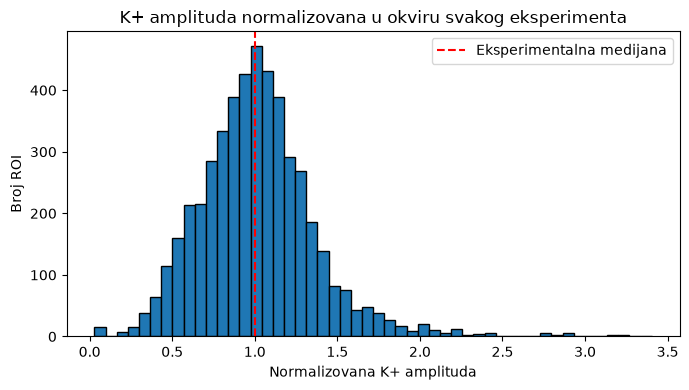

In [38]:
# Vizuelizacija raspodele
plt.figure(figsize=(7, 4))

plt.hist(
    analysis_df["relative_k_amplitude"],
    bins=50,
    edgecolor="black",
)

plt.axvline(
    1.0,
    linestyle="--",
    color="red",
    label="Eksperimentalna medijana",
)

plt.xlabel("Normalizovana K+ amplituda")
plt.ylabel("Broj ROI")
plt.title("K+ amplituda normalizovana u okviru svakog eksperimenta")
plt.legend()
plt.tight_layout()
plt.show()

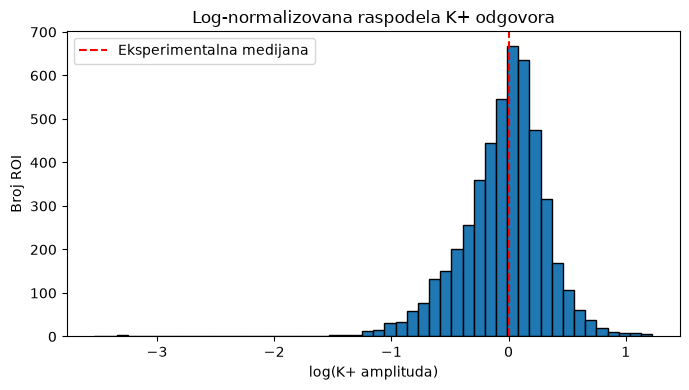

In [39]:
# Log-transformacija
plt.figure(figsize=(7, 4))

plt.hist(
    analysis_df["log_relative_k_amplitude"],
    bins=50,
    edgecolor="black",
)

plt.axvline(
    0.0,
    linestyle="--",
    color="red",
    label="Eksperimentalna medijana",
)

plt.xlabel("log(K+ amplituda)")
plt.ylabel("Broj ROI")
plt.title("Log-normalizovana raspodela K+ odgovora")
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
# GMM sa normalizovanim vrednostima
X_relative = (
    analysis_df["log_relative_k_amplitude"]
    .dropna()
    .to_numpy()
    .reshape(-1, 1)
)

relative_gmm_rows = []

for n_components in [1, 2, 3]:
    gmm = GaussianMixture(
        n_components=n_components,
        random_state=RANDOM_STATE,
    )

    gmm.fit(X_relative)

    relative_gmm_rows.append(
        {
            "n_components": n_components,
            "bic": gmm.bic(X_relative),
            "aic": gmm.aic(X_relative),
        }
    )

relative_gmm_comparison = pd.DataFrame(
    relative_gmm_rows
)

relative_gmm_comparison

,n_components,bic,aic
0,1,4832.258056,4819.273485
1,2,3952.434941,3919.973513
2,3,3909.584505,3857.646220


In [41]:
# Fitovanje dvokomponentnog modela
relative_gmm_2 = GaussianMixture(
    n_components=2,
    random_state=RANDOM_STATE,
)

relative_gmm_2.fit(X_relative)

,"n_components n_components: int, default=1The number of mixture components.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None


In [42]:
# Kriva gustine
x_grid = np.linspace(
    X_relative.min(),
    X_relative.max(),
    1000,
).reshape(-1, 1)

component_means = relative_gmm_2.means_.ravel()
component_vars = relative_gmm_2.covariances_.ravel()
component_sds = np.sqrt(component_vars)
component_weights = relative_gmm_2.weights_.ravel()

component_densities = []

for mean, sd, weight in zip(
    component_means,
    component_sds,
    component_weights,
):
    density = (
        weight
        * (1 / (sd * np.sqrt(2 * np.pi)))
        * np.exp(
            -0.5
            * ((x_grid.ravel() - mean) / sd) ** 2
        )
    )

    component_densities.append(density)

total_density = np.sum(
    component_densities,
    axis=0,
)

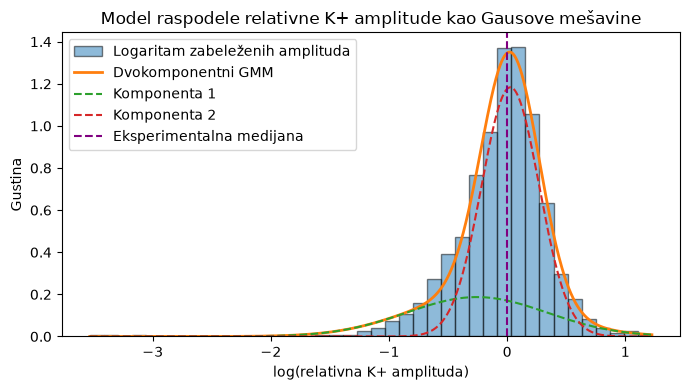

In [43]:
# Vizuelizacija
plt.figure(figsize=(7, 4))

plt.hist(
    X_relative.ravel(),
    bins=40,
    density=True,
    alpha=0.5,
    edgecolor="black",
    label="Logaritam zabeleženih amplituda",
)

plt.plot(
    x_grid.ravel(),
    total_density,
    linewidth=2,
    label="Dvokomponentni GMM",
)

for i, density in enumerate(component_densities):
    plt.plot(
        x_grid.ravel(),
        density,
        linestyle="--",
        label=f"Komponenta {i + 1}",
    )

plt.axvline(
    0, 
    linestyle="--",
    color="purple",
    label="Eksperimentalna medijana",
)
plt.xlabel("log(relativna K+ amplituda)")
plt.ylabel("Gustina")
plt.title("Model raspodele relativne K+ amplitude kao Gausove mešavine")
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
# Identifikacija komponente sa slabim odgovorom
relative_low_component = np.argmin(
    relative_gmm_2.means_.ravel()
)

relative_component_probabilities = relative_gmm_2.predict_proba(X_relative)

relative_low_component_probability = (
    relative_component_probabilities[:, relative_low_component]
)

# Dodavanje vrednosti u tabelu
analysis_df["relative_weak_k_component_probability"] = (
    relative_low_component_probability
)

analysis_df["relative_weak_k_component_flag_90"] = (
    analysis_df["relative_weak_k_component_probability"] >= 0.90
)

analysis_df["relative_weak_k_component_flag_75"] = (
    analysis_df["relative_weak_k_component_probability"] >= 0.75
)

In [45]:
# Provera raspodele verovatnoće pripadanja slaboj komponenti
analysis_df[
    [
        "relative_weak_k_component_probability",
    ]
].describe()

,relative_weak_k_component_probability
count,4877.000000
mean,0.274632
std,0.244792
min,0.121299
25%,0.127199
50%,0.155000
75%,0.286114
max,1.000000


In [46]:
# Broj ROI s datom verovatnoćom pripadanja slaboj komponenti
analysis_df[
    [
        "relative_weak_k_component_flag_90",
        "relative_weak_k_component_flag_75",
    ]
].sum()

relative_weak_k_component_flag_90    285
relative_weak_k_component_flag_75    451
dtype: int64

In [47]:
# Procena granične vrednosti
relative_grid_probabilities = relative_gmm_2.predict_proba(x_grid)

relative_low_component_grid_probability = (
    relative_grid_probabilities[:, relative_low_component]
)

# Tačka sa 50% verovatnoćom pripadanja obema komponentama
relative_threshold_index = np.argmin(
    np.abs(relative_low_component_grid_probability - 0.5)
)

relative_log_threshold = x_grid.ravel()[relative_threshold_index]
relative_amplitude_threshold = np.exp(relative_log_threshold)

relative_amplitude_threshold

np.float64(0.6397326762935985)

In [48]:
# Obeležavanje ROI ispod granice
analysis_df["relative_weak_k_below_gmm_threshold"] = (
    analysis_df["relative_k_amplitude"]
    < relative_amplitude_threshold
)

analysis_df["relative_weak_k_below_gmm_threshold"].value_counts()

relative_weak_k_below_gmm_threshold
False    4241
True      636
Name: count, dtype: int64

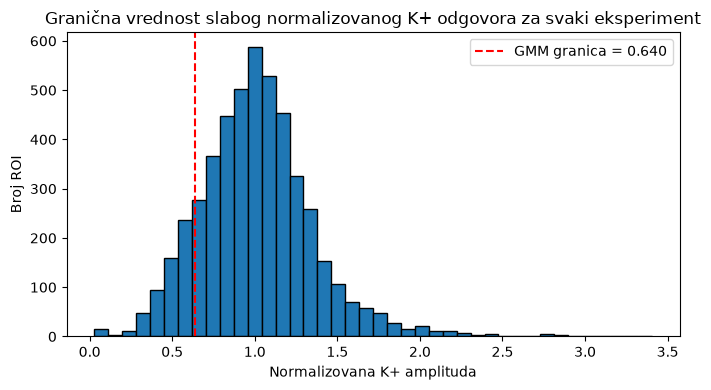

In [49]:
# Vizuelizacija
plt.figure(figsize=(7, 4))

plt.hist(
    analysis_df["relative_k_amplitude"],
    bins=40,
    edgecolor="black",
)

plt.axvline(
    relative_amplitude_threshold,
    linestyle="--",
    color="red",
    label=f"GMM granica = {relative_amplitude_threshold:.3f}",
)

plt.xlabel("Normalizovana K+ amplituda")
plt.ylabel("Broj ROI")
plt.title("Granična vrednost slabog normalizovanog K+ odgovora za svaki eksperiment")
plt.legend()
plt.tight_layout()
plt.show()

Na osnovu rezultata GMM, vidimo da i nakon normalizacije amplituda, raspodela vrednosti zadržava izvesnu asimetriju ili više pojedinačnih regiona. Naravno, to i dalje ne znači da postoje dva, tri ili više tipa ćelija u svakom eksperimentu - jednostavno nam govori da se postojeća raspodela može matematički bolje okarakterisati većim brojem pojedinačnih komponenti. Svakako ne možemo govoriti o dve relativno dobro definisane populacije ćelija, jer vidimo da je preklapanje raspodela u GMM dvokomponentnom modelu veoma izraženo - medijalna verovatnoća pripadanja niskoj komponenti na nivou ROI je `0.155`, dok je minimalna verovatnoća čak `0.121`. Dakle, zaključujemo da verovatnoće zauzimaju kontinuum vrednosti i da je teško identifikovati određenu graničnu vrednost, čak i u okviru pojedinačnih eksperimenata.

Ono što dalje možemo ispitati jeste postojanje autlajera u okviru svakog eksperimenta. Autlajeri se mogu identifikovati preko **z-vrednosti**, koja govori koliko se neka vrednost razlikuje od srednje vrednosti u jedinicama standardne devijacije:

\begin{equation}
    z = \frac{x - \overline{x}}{s}
\end{equation}

Međutim, ova mera je osetljiva na prisustvo ekstremnih vrednosti, pa je bolje koristiti **robusnu z-vrednost**, koja umesto srednje vrednosti koristi medijanu i medijalnu apsolutnu devijaciju (MAD), koja se računa kao:

\begin{equation}
    MAD = median(|x_i - median(x)|)
\end{equation}

i koja daje meru apsolutne razlike svakog zapažanja i medijalne vrednosti. Robusna z-vrednost se računa kao:

\begin{equation}
    z_{robust} = 0.6745 \frac{x - median(x)}{MAD}
\end{equation}

In [50]:
# Procena autlajera u okviru svakog eksperimenta
def add_robust_k_scores(group):
    values = group["k_ref_amplitude"]

    median = values.median()

    mad = np.median(
        np.abs(values - median)
    )

    group = group.copy()

    if mad == 0 or np.isnan(mad):
        group["k_robust_z"] = np.nan
    else:
        group["k_robust_z"] = (
            0.6745
            * (values - median)
            / mad
        )

    return group

In [51]:
# Dodavanje vrednosti u tabelu
analysis_df = (
    analysis_df
    .groupby(
        "experiment_source_id",
        group_keys=False,
    )
    .apply(add_robust_k_scores)
)

In [52]:
# Definisanje dve granične vrednosti
analysis_df["weak_k_robust_flag_3"] = (
    analysis_df["k_robust_z"] < -3
)

analysis_df["weak_k_robust_flag_2_5"] = (
    analysis_df["k_robust_z"] < -2.5
)

In [53]:
# Prikaz rezultata
robust_weak_summary = (
    analysis_df
    .groupby("experiment_label")
    .agg(
        n_rois=("record_id", "count"),
        median_k_amplitude=(
            "k_ref_amplitude",
            "median",
        ),
        n_weak_z3=(
            "weak_k_robust_flag_3",
            "sum",
        ),
        fraction_weak_z3=(
            "weak_k_robust_flag_3",
            "mean",
        ),
        n_weak_z2_5=(
            "weak_k_robust_flag_2_5",
            "sum",
        ),
        fraction_weak_z2_5=(
            "weak_k_robust_flag_2_5",
            "mean",
        ),
    )
    .reset_index()
)

robust_weak_summary

,experiment_label,n_rois,median_k_amplitude,n_weak_z3,fraction_weak_z3,n_weak_z2_5,fraction_weak_z2_5
0,10a_1..10 | 2023_11_01_CGNs_isolated3010_CSF_1,151,1.291793,0,0.000000,0,0.000000
1,10a_1..10 | 2023_11_01_CGNs_isolated3010_CSF_2,208,2.301310,0,0.000000,0,0.000000
2,10a_1..100 | 2023_11_02_CGNs_isolated3010_CSF_4,192,3.888979,0,0.000000,1,0.005208
3,10a_1..100 | 2023_11_02_CGNs_isolated3010_CSF_5,145,4.150527,1,0.006897,3,0.020690
4,10a_1..100 | 2023_11_02_CGNs_isolated3010_CSF_...,193,4.274645,4,0.020725,9,0.046632
5,10a_1..100 | 2023_11_02_CGNs_isolated3010_CSF_7,146,4.568103,2,0.013699,5,0.034247
6,10a_1..25 | 2023_11_01_CGNs_isolated3010_CSF_3,229,2.013582,0,0.000000,0,0.000000
7,10a_1..25 | 2023_11_01_CGNs_isolated3010_CSF_4...,240,2.753613,0,0.000000,0,0.000000
8,10a_1..25 | 2023_11_01_CGNs_isolated3010_CSF_5,204,2.791988,0,0.000000,0,0.000000
9,10a_1..50 | 2023_11_01_CGNs_isolated3010_CSF_7...,169,3.493309,3,0.017751,3,0.017751


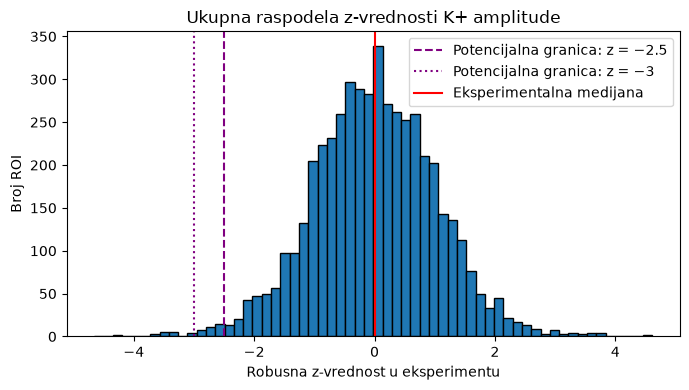

In [54]:
# Vizuelizacija raspodele robusnih z-vrednosti
plt.figure(figsize=(7, 4))

plt.hist(
    analysis_df["k_robust_z"].dropna(),
    bins=60,
    edgecolor="black",
)

plt.axvline(
    -2.5,
    linestyle="--",
    color="purple",
    label="Potencijalna granica: z = −2.5",
)

plt.axvline(
    -3.0,
    linestyle=":",
    color="purple",
    label="Potencijalna granica: z = −3",
)

plt.axvline(
    0,
    linestyle="-",
    color="red",
    label="Eksperimentalna medijana",
)

plt.xlabel("Robusna z-vrednost u eksperimentu")
plt.ylabel("Broj ROI")
plt.title("Ukupna raspodela z-vrednosti K+ amplitude")
plt.legend()
plt.tight_layout()
plt.show()

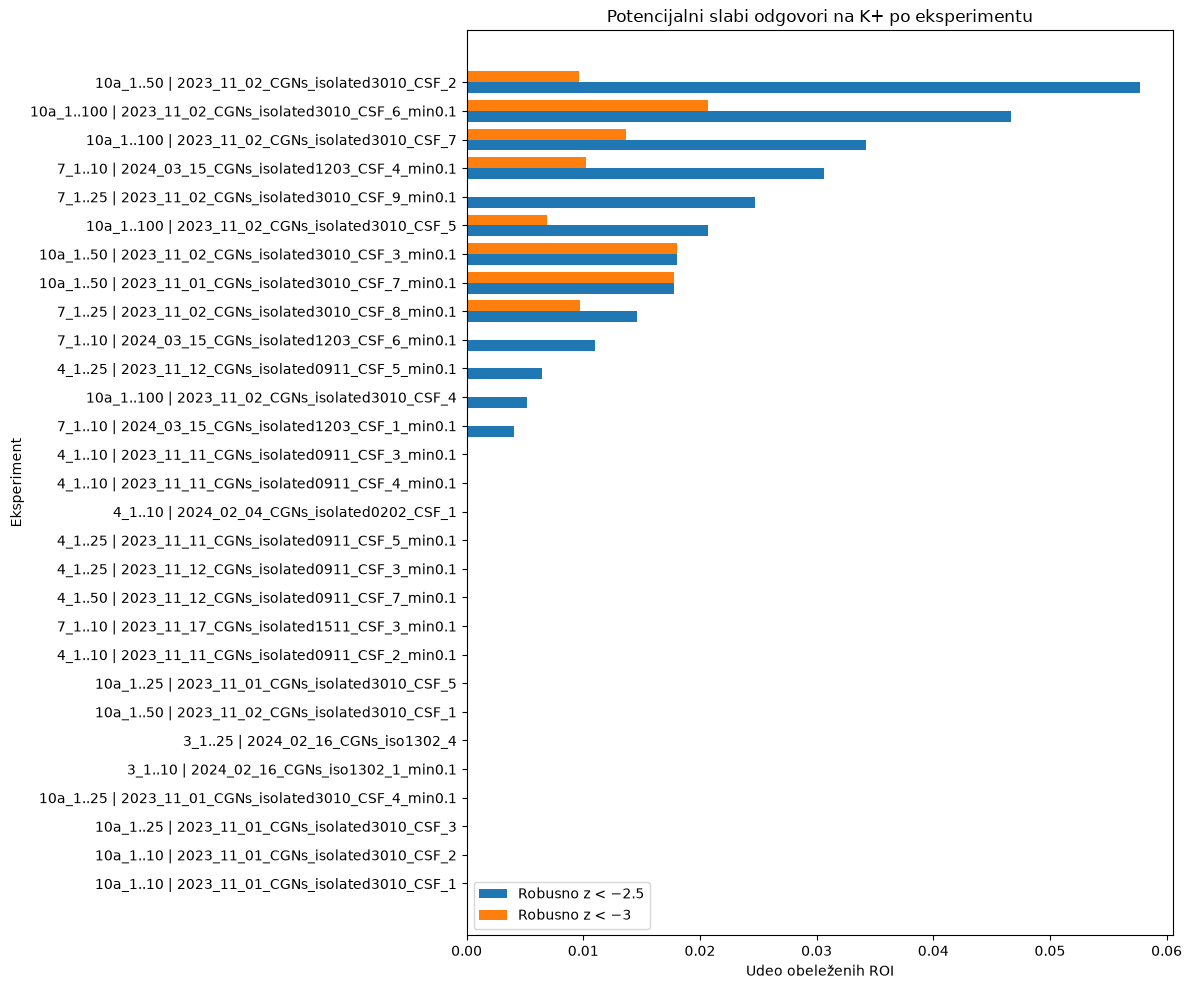

In [55]:
# Vizuelizacija udela obeleženih ROI po eksperimentu
robust_plot_data = (
    robust_weak_summary
    .sort_values(
        "fraction_weak_z2_5",
        ascending=True,
    )
    .reset_index(drop=True)
)

y_positions = np.arange(
    len(robust_plot_data)
)

bar_height = 0.38

plt.figure(figsize=(12,10))

plt.barh(
    y_positions - bar_height / 2,
    robust_plot_data["fraction_weak_z2_5"],
    height=bar_height,
    label="Robusno z < −2.5",
)

plt.barh(
    y_positions + bar_height / 2,
    robust_plot_data["fraction_weak_z3"],
    height=bar_height,
    label="Robusno z < −3",
)

plt.yticks(
    y_positions,
    robust_plot_data["experiment_label"],
)

plt.xlabel("Udeo obeleženih ROI")
plt.ylabel("Eksperiment")
plt.title("Potencijalni slabi odgovori na K+ po eksperimentu")
plt.legend()
plt.tight_layout()
plt.show()

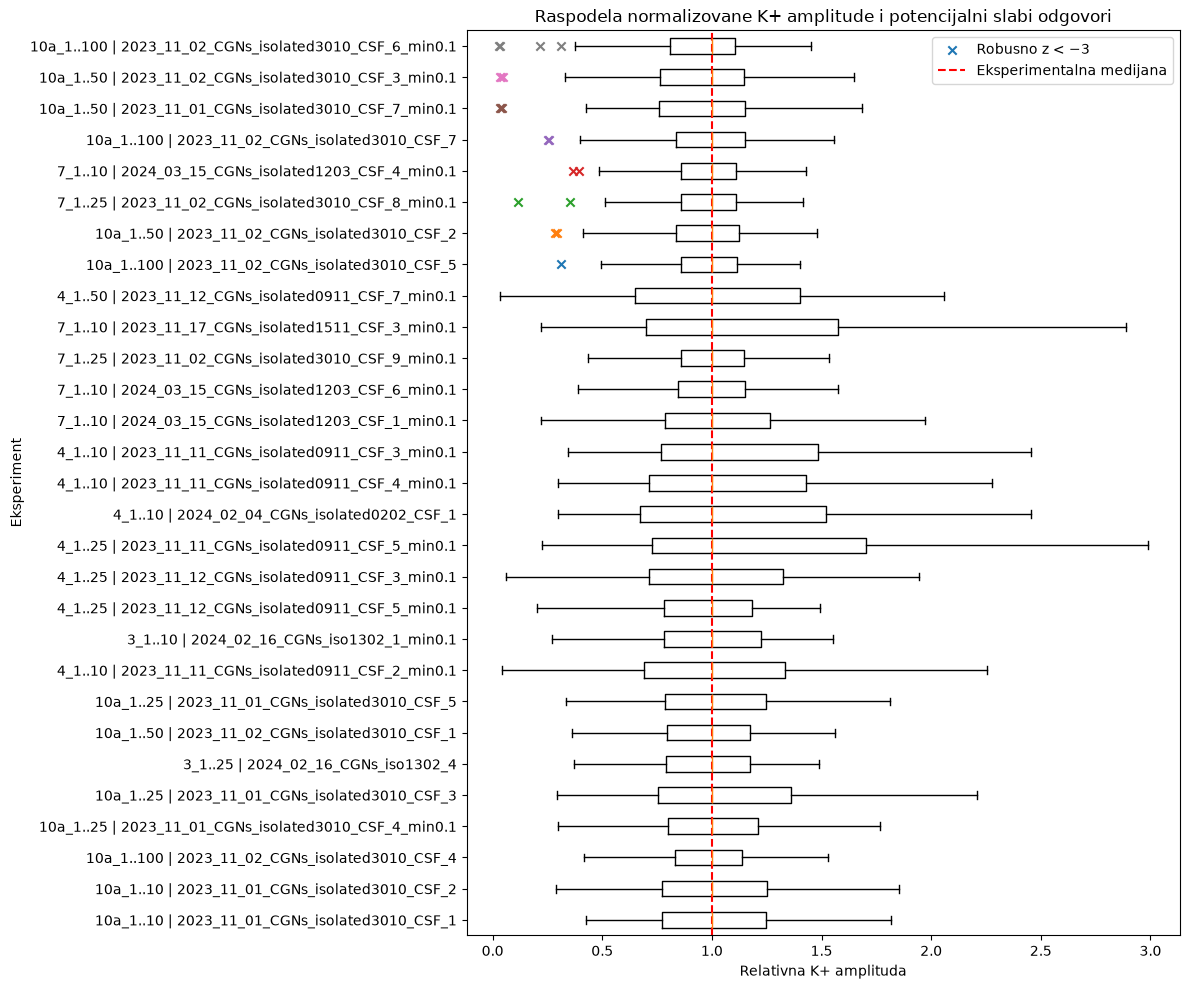

In [56]:
# Zajednički prikaz normalizovane raspodele i autlajera po eksperimentu
experiment_order = (
    robust_weak_summary
    .sort_values("fraction_weak_z3")
    ["experiment_label"]
    .tolist()
)

boxplot_data = [
    analysis_df.loc[
        analysis_df["experiment_label"]
        == experiment,
        "relative_k_amplitude",
    ].dropna()
    for experiment in experiment_order
]

plt.figure(figsize=(12, 10))

plt.boxplot(
    boxplot_data,
    tick_labels=experiment_order,
    orientation="horizontal",
    showfliers=False,
)

label_added = False

for position, experiment in enumerate(
    experiment_order,
    start=1,
):
    flagged_values = analysis_df.loc[
        (
            analysis_df["experiment_label"]
            == experiment
        )
        & analysis_df["weak_k_robust_flag_3"],
        "relative_k_amplitude",
    ]

    if not flagged_values.empty:
        plt.scatter(
            flagged_values,
            np.repeat(position, len(flagged_values)),
            marker="x",
            label=(
                "Robusno z < −3"
                if not label_added
                else None
            ),
        )

        label_added = True

plt.axvline(
    1,
    linestyle="--",
    color="red",
    label="Eksperimentalna medijana",
)

plt.xlabel("Relativna K+ amplituda")
plt.ylabel("Eksperiment")
plt.title("Raspodela normalizovane K+ amplitude i potencijalni slabi odgovori")

if label_added:
    plt.legend()

plt.tight_layout()
plt.show()

Nakon ispitivanja z-vrednosti, dobili smo sasvim drugačije rezultate nego prilikom modeliranja raspodele apsolutnih vrednosti K+ amplitude pomoću GMM. Korišćenje z-vrednosti za identifikaciju autlajera obeležava svega `19`, odnosno `54` ROI kao slabe u zavisnosti od odabrane granične vrednosti. Pritom, svaki pojedinačni eksperiment ima mali udeo obeleženih ROI. Ovo nam ponovo ilustruje da su ROI sa niskom amplitudom uglavnom poreklom od eksperimenata koji u celosti pokazuju nisku amplitudu odgovora. 

#### Zaključak

Na osnovu urađenih analiza, zaključujemo da amplitude odgovora na K+ među ćelijama imaju heterogenu i multimodalnu raspodelu, kao i da se opseg amplituda među ćelijama značajno razlikuje među eksperimentima. Kada se posmatraju sve ćelije zajedno, uočava se da ćelije sa slabijim odgovorom gotovo univerzalno potiču od eksperimenata koji se u celosti odlikuju nižom postignutom amplitudom odgovora na K+. Unutar pojedinačnih eksperimenata, nisu identifikovane značajne populacije ćelija sa nekarakteristično niskim odgovorom. 

Postavljanje univerzalne granice K+ amplitude moglo bi diskvalifikovati veliki udeo ROI iz određenih eksperimenata, a bez informacija o mogućim razlozima zbog kojih se ćelije u pomenutim eksperimentima ponašaju na taj način, i na osnovu trenutno dostupnih podataka, teško je opravdati uvođenje ovakve granice. 